# 01 - Visualisation du dataset

## Objectif

Ce notebook sert à vérifier que le dataset est bien organisé, à compter les images par classe et à afficher quelques exemples de pièces OK et Defective.

## 1. Préparation de l'environnement

On ajoute la racine du projet au chemin Python pour pouvoir importer les fonctions du dossier `src/`.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import read_grayscale_image
from src.utils import build_image_index, dataset_summary, display_images, ensure_project_directories, sample_by_class

## 2. Chargement de l'index du dataset

Le code parcourt automatiquement la structure demandée : `data/raw/casting_data/train` et `data/raw/casting_data/test`.

In [2]:
ensure_project_directories()
index_df = build_image_index()

print(f"Nombre total d'images trouvées : {len(index_df)}")
display(index_df.head())
display(dataset_summary(index_df))

Nombre total d'images trouvées : 7348


,path,filename,split,class_folder,label,label_name
0,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1.jpeg,train,ok_front,0,OK
1,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1001.jpeg,train,ok_front,0,OK
2,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1002.jpeg,train,ok_front,0,OK
3,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1003.jpeg,train,ok_front,0,OK
4,C:\Users\espacegamers\Desktop\Master IAII\Cour...,cast_ok_0_1005.jpeg,train,ok_front,0,OK


,split,label_name,count
0,test,Defective,453
1,test,OK,262
2,train,Defective,3758
3,train,OK,2875


## 3. Répartition des classes

Cette étape permet de voir si les classes sont équilibrées ou non.

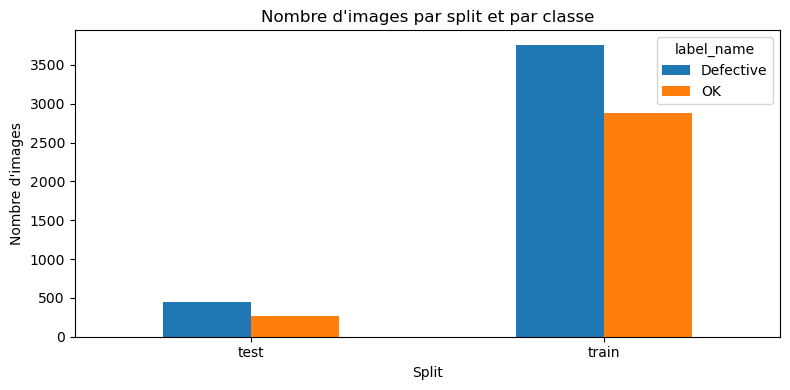

In [3]:
summary = dataset_summary(index_df)

if summary.empty:
    print("Aucune image trouvée. Placez le dataset dans data/raw/casting_data/.")
else:
    pivot = summary.pivot(index="split", columns="label_name", values="count").fillna(0)
    ax = pivot.plot(kind="bar", figsize=(8, 4), rot=0)
    ax.set_title("Nombre d'images par split et par classe")
    ax.set_xlabel("Split")
    ax.set_ylabel("Nombre d'images")
    plt.tight_layout()
    plt.show()

## 4. Affichage de quelques images

On affiche plusieurs images de chaque classe pour observer visuellement les différences.

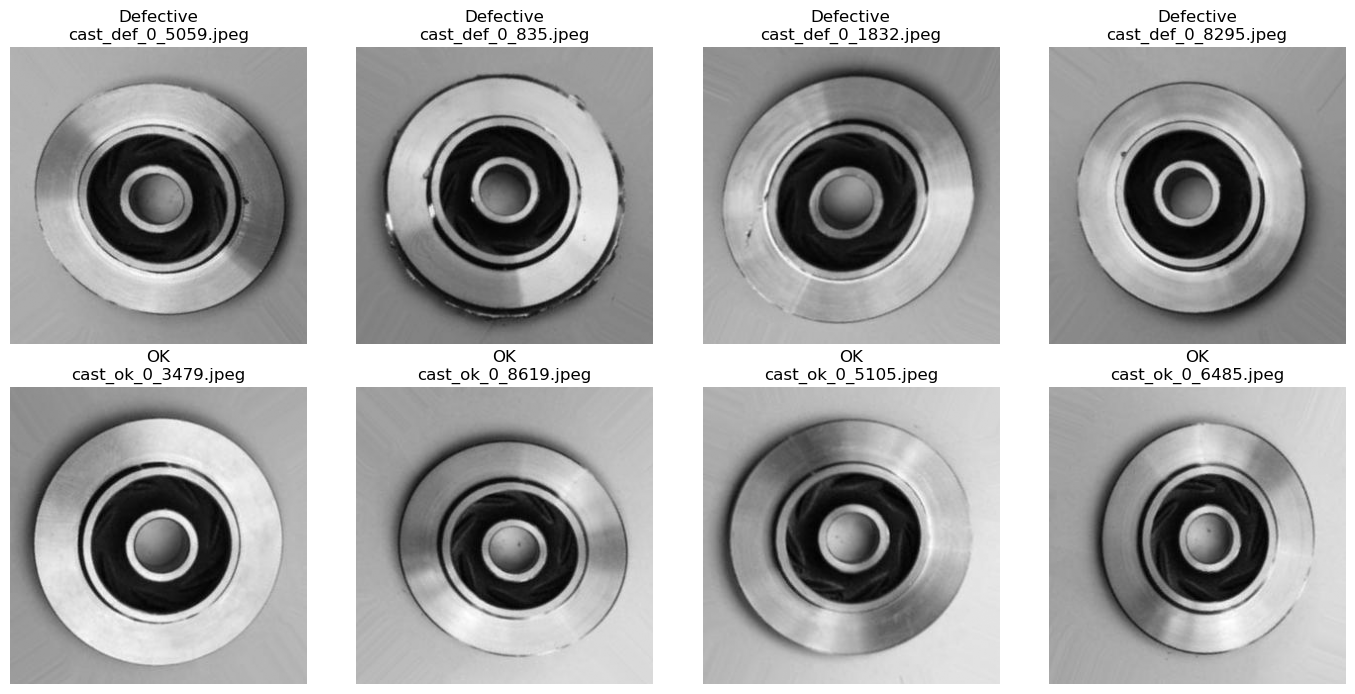

In [4]:
samples = sample_by_class(index_df, split="train", n_per_class=4)

if samples.empty:
    print("Aucun exemple à afficher.")
else:
    images = [read_grayscale_image(path) for path in samples["path"]]
    titles = [f"{row.label_name}\n{row.filename}" for row in samples.itertuples()]
    display_images(images, titles=titles, cols=4, figsize=(14, 7))

## Conclusion

À ce stade, on connaît la taille du dataset, la répartition des classes et l'apparence générale des images. Cela permet de commencer le prétraitement avec une idée claire des données.